In [65]:
from dotenv import load_dotenv
import os
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, Sequence
from langchain_core.messages import HumanMessage, ToolMessage, BaseMessage, SystemMessage
from operator import add as add_messages
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langchain_core.tools import tool

load_dotenv()
model=ChatOpenAI(model="gpt-4-turbo")
embeddings = OpenAIEmbeddings(
    model="text-embedding-3-small"
)

 


In [66]:
pdf_path="stock.pdf"

In [67]:
#load the file
if not os.path.exists(pdf_path):
    raise FileNotFoundError(f"{pdf_path} not found. Please make sure the file exist in the curr directory")
pdf_loader=PyPDFLoader(pdf_path)

In [68]:
try:
    pages=pdf_loader.load()
    print(f"PDF has been loaded and has {len(pages)} pages.")
except Exception as e:
    print(f"An error occured while loading the PDF: {e}")
    raise

Ignoring wrong pointing object 18 0 (offset 0)
Ignoring wrong pointing object 149 0 (offset 0)
Ignoring wrong pointing object 299 0 (offset 0)
Ignoring wrong pointing object 489 0 (offset 0)
Ignoring wrong pointing object 491 0 (offset 0)


PDF has been loaded and has 103 pages.


In [69]:
#text splitter
text_splitter=RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

In [70]:
pages_split=text_splitter.split_documents(pages)
print(f"Total Chunks: {len(pages_split)}")

Total Chunks: 227


In [71]:
#vector database

collection_name="stock_market"

try:
    vectorstore=Chroma.from_documents(
        documents=pages_split,
        embedding=embeddings,
        collection_name=collection_name
    )
    print(f"Vectorstore created with collection name: {collection_name}")
except Exception as e:
    print(f"An error occured while creating the vectorstore: {e}")
    raise

Vectorstore created with collection name: stock_market


In [72]:
#retreiver

retriever=vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k":3}
)

In [73]:
@tool
def retriever_tool(query:str)->str:
    """This tool searches and returns information from the stock document"""
    docs=retriever.invoke(query)
    if not docs:
        return "No relevant information found in the document"
    results=[]
    for i, doc in enumerate(docs):
        results.append(f"Source {i+1}:\n{doc.page_content}\n")
    return "\n".join(results)

tool=[retriever_tool]
llm=model.bind_tools(tool)

In [74]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [75]:
def should_continue(state:AgentState):
    """check if the last message contains tool calls"""
    result=state["messages"][-1]
    return hasattr(result, "tool_calls") and len(result.tool_calls)>0

In [76]:
system_prompt="""
you are an intelligent AI assistant who answers questions about stock market performance in 2026 based on the PDF document loaded into your knowledge base.
use the retriever tool available to answer questions about the stock market performance data. you can make multiple calls if needed.
if you need to look up some information before asking a follow up question, you are allowed to do that!
Please always cite the specific parts of th documents you use in your answers

"""

In [77]:
tool_dict={our_tool.name: our_tool for our_tool in tool}

In [78]:
#LLM Agent
def call_llm(state:AgentState)->AgentState:
    """Function to call the llm with the current state"""
    messages=list(state['messages'])
    messages=[SystemMessage(content=system_prompt)]+messages
    message=llm.invoke(messages)
    return {'messages':[message]}

In [79]:
#retriever agent
def take_action(state:AgentState)->AgentState:
    """Function to execute tools from the llm's response"""
    tool_calls=state['messages'][-1].tool_calls
    results=[]
    
    for t in tool_calls:
        # print(f"Executing tool:{t.name} with input: {t.input}")
        print(f"Executing tool: {t['name']} with input: {t['args']}")
        if not t['name'] in tool_dict:
           result=f"tool {t['name']} not found."
        else:
            result=tool_dict[t['name']].invoke(t['args'].get('query', ''))
            print(f"Tool result: {result}")
        #append the tool message
        
        results.append(ToolMessage(tool_call_id=t['id'], name=t['name'], content=str(result)))
    print("Tools executed.")
    return {'messages': results} 

In [80]:
graph= StateGraph(AgentState)
graph.add_node("llm", call_llm)
graph.add_node("retriever_agent", take_action)
graph.add_edge(START, 'llm')
graph.add_conditional_edges(
    "llm",
    should_continue,
    {
        True:'retriever_agent',
        False:END
    }
)
graph.add_edge("retriever_agent", "llm")

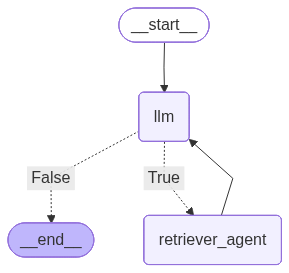

In [81]:
rag_agent=graph.compile()
rag_agent

In [82]:
def running_agent():
    while True:
        user_input=input("what is your question?")
        if user_input.lower() in ["exit", "quit"]:
            print("Exiting the agent.")
            break
        messages=[HumanMessage(content=user_input)]
        result=rag_agent.invoke({'messages' : messages})
        print("Agent Response:")
        print(result['messages'][-1].content)
        
running_agent()

Executing tool: retriever_tool with input: {'query': 'document summary'}
Tool result: Source 1:
WHAT ARE THE THREE FINANCIAL STATEMENTS? .................................................................................54
THE BALANCE SHEET ..........................................................................................................................................54
SECTION 2 .................................................................................................................................................................56
THE INCOME STATEMENT ................................................................................................................................56
THE STATEMENT OF CASH FLOWS ................................................................................................................57
SECTION 3  ............................................................................................................................................